This notebook prepares transcriptomic representations for evaluating cross-donor generalization in cell-type annotation using healthy control PBMCs from the Stephenson et al. 2021 dataset. We filter to healthy donors, downsample to 500 cells per donor, and generate four representations: HVG log-normalized expression, PCA, Harmony-corrected PCs, and scVI embeddings. These representations will be used to benchmark cell-type classification under random cell-level splits versus donor-held-out splits.

In [ ]:
# Data handling
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
import pertpy as pt

# Integration methods
import harmonypy as hm
import scvi

# File handling
from pathlib import Path
import os

/users/xchen5/.local/lib/python3.9/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)


In [97]:
# set repo root, CHANGE to your own path where the repository root is hosted
REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)

**Read in Data (Run either of the Blocks)**

In [ ]:
adata = pt.data.stephenson_2021_subsampled()

In [125]:
# for local loads, if pertpy is not available, use the following code to load the data directly from the h5ad file. Make sure to update the path to the h5ad file accordingly.
adata = sc.read_h5ad("data/stephenson_2021_subsampled.h5ad")

**Filter Data to Control Samples, 500 Cells Each**

In [126]:
# RE-USE this script in all notebooks
# focus on healthy control samples only - in the dataset, this is the "Healthy" classification in "status" column (exclues COVID and LPS samples)
# in addition, each sample should only contain 500 cells for fairness in comparison across donors
adata_ctrl = adata[adata.obs["Status"] == "Healthy"].copy()

# downsample to 500 cells per donor if there are more than 500 cells for that donor, otherwise keep all cells for that donor
cells_to_keep = []

# Set global seed
np.random.seed(42)

for donor, idx in adata_ctrl.obs.groupby("patient_id", observed=True).groups.items():
    idx = np.array(list(idx))
    
    if len(idx) > 500:
        cells_to_keep.extend(np.random.choice(idx, 500, replace=False))
    else:
        cells_to_keep.extend(idx)

adata_ctrl = adata_ctrl[cells_to_keep].copy()

print("Control cells:", adata_ctrl.n_obs)
print("Control donors:", adata_ctrl.obs["patient_id"].nunique())

Control cells: 11290
Control donors: 23


**Normalize + Log Transform**

In [127]:
# Check the range of values in adata_ctrl.X
print(f"Min value: {adata_ctrl.X.min()}")
print(f"Max value: {adata_ctrl.X.max()}")
print(f"Mean value: {adata_ctrl.X.mean()}")

Min value: 0.0
Max value: 7.610828399658203
Mean value: 0.0767652839422226


In [128]:
# Check total counts per cell
total_counts = np.array(adata_ctrl.X.sum(axis=1)).flatten()
print(f"Total counts per cell - Min: {total_counts.min():.2f}, Max: {total_counts.max():.2f}")
print(f"Mean: {total_counts.mean():.2f}, Std: {total_counts.std():.2f}")

Total counts per cell - Min: 593.39, Max: 1871.05
Mean: 1251.20, Std: 166.32


Data already log-transformed and normalized, skipping these steps.

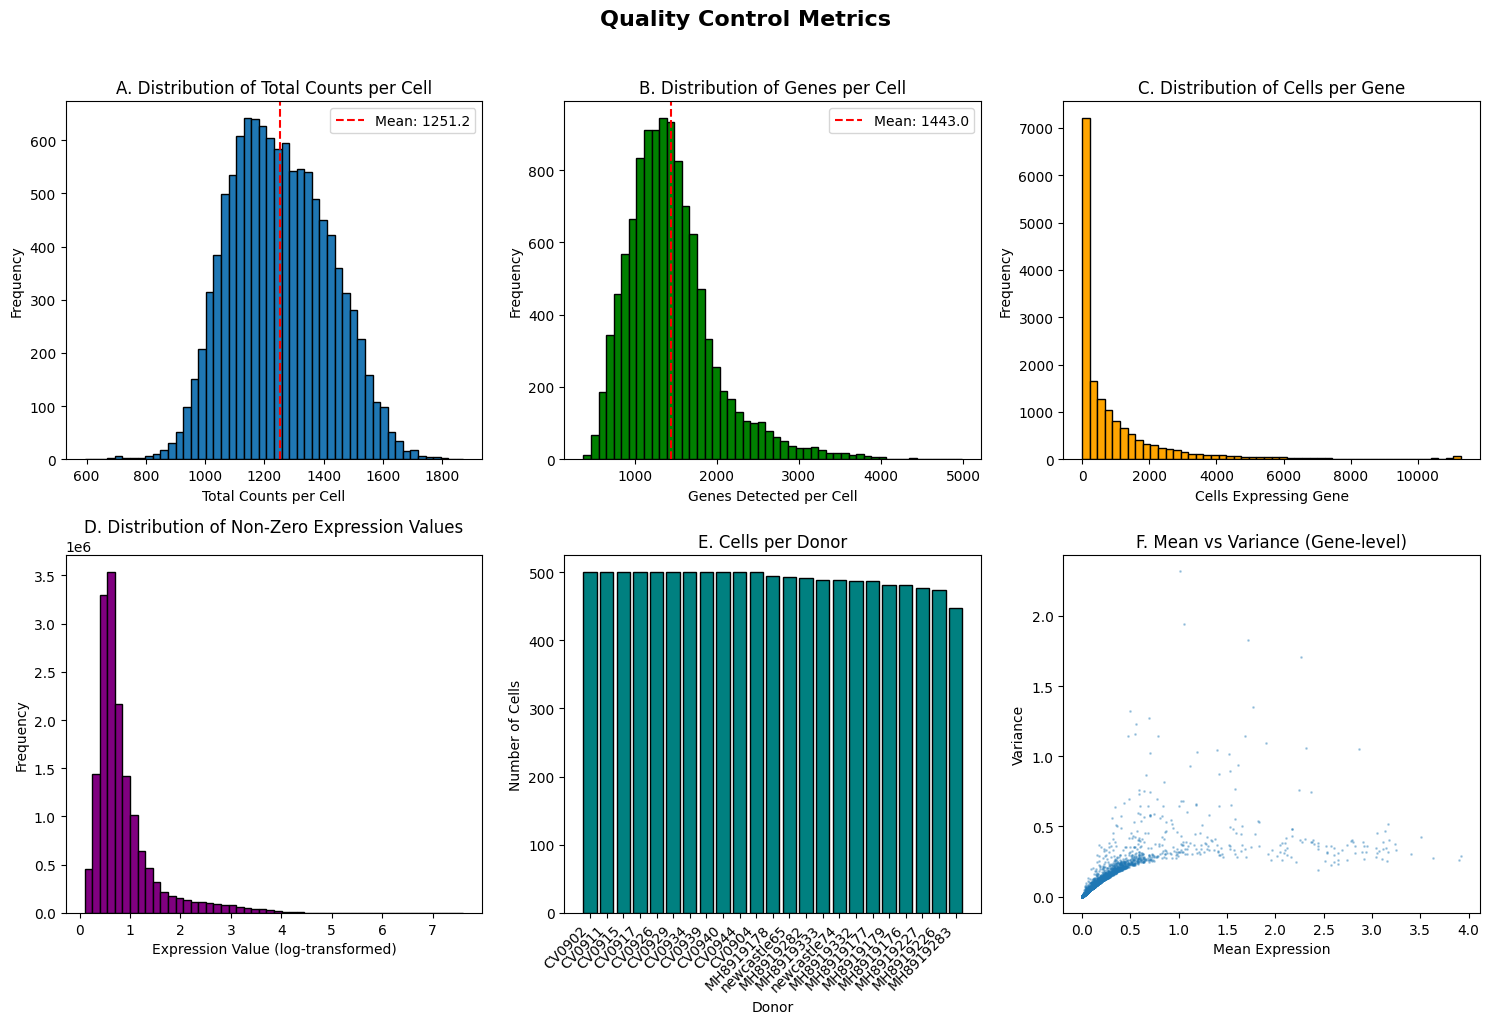


Saved: results/figures/qc_metrics.png'


In [129]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Add main title
fig.suptitle('Quality Control Metrics', fontsize=16, fontweight='bold', y=1.02)

# 1a. Total counts per cell
total_counts = np.array(adata_ctrl.X.sum(axis=1)).flatten()
axes[0, 0].hist(total_counts, bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Total Counts per Cell')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('A. Distribution of Total Counts per Cell')
axes[0, 0].axvline(np.mean(total_counts), color='red', linestyle='--', label=f'Mean: {np.mean(total_counts):.1f}')
axes[0, 0].legend()

# 1b. Genes detected per cell
genes_per_cell = np.array((adata_ctrl.X > 0).sum(axis=1)).flatten()
axes[0, 1].hist(genes_per_cell, bins=50, edgecolor='black', color='green')
axes[0, 1].set_xlabel('Genes Detected per Cell')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('B. Distribution of Genes per Cell')
axes[0, 1].axvline(np.mean(genes_per_cell), color='red', linestyle='--', label=f'Mean: {np.mean(genes_per_cell):.1f}')
axes[0, 1].legend()

# 1c. Cells per gene
cells_per_gene = np.array((adata_ctrl.X > 0).sum(axis=0)).flatten()
axes[0, 2].hist(cells_per_gene, bins=50, edgecolor='black', color='orange')
axes[0, 2].set_xlabel('Cells Expressing Gene')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('C. Distribution of Cells per Gene')

# 1d. Expression value distribution (sample)
sample_expr = adata_ctrl.X.toarray().flatten() if hasattr(adata_ctrl.X, 'toarray') else adata_ctrl.X.flatten()
sample_expr = sample_expr[sample_expr > 0]  # Non-zero values only
axes[1, 0].hist(sample_expr, bins=50, edgecolor='black', color='purple')
axes[1, 0].set_xlabel('Expression Value (log-transformed)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('D. Distribution of Non-Zero Expression Values')

# 1e. Cells per donor
donor_counts = adata_ctrl.obs['patient_id'].value_counts()
axes[1, 1].bar(range(len(donor_counts)), donor_counts.values, edgecolor='black', color='teal')
axes[1, 1].set_xlabel('Donor')
axes[1, 1].set_ylabel('Number of Cells')
axes[1, 1].set_title('E. Cells per Donor')
axes[1, 1].set_xticks(range(len(donor_counts)))
axes[1, 1].set_xticklabels(donor_counts.index, rotation=45, ha='right')

# 1f. Mean expression vs variance (for HVG intuition)
mean_expr = np.array(adata_ctrl.X.mean(axis=0)).flatten()
var_expr = np.array(adata_ctrl.X.toarray().var(axis=0)).flatten() if hasattr(adata_ctrl.X, 'toarray') else np.array(adata_ctrl.X.var(axis=0)).flatten()
axes[1, 2].scatter(mean_expr, var_expr, alpha=0.3, s=1)
axes[1, 2].set_xlabel('Mean Expression')
axes[1, 2].set_ylabel('Variance')
axes[1, 2].set_title('F. Mean vs Variance (Gene-level)')

plt.tight_layout()
# plt.savefig(figures_dir / 'qc_metrics.png', dpi=300, bbox_inches='tight')
plt.savefig('results/figures/qc_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: results/figures/qc_metrics.png'")

**Find Highly Variable Genes**

In [130]:
sc.pp.highly_variable_genes(adata_ctrl, n_top_genes=2000, batch_key="patient_id")

print(f"Number of HVGs: {adata_ctrl.var['highly_variable'].sum()}")

Number of HVGs: 2000


In [131]:
# Store Full Data in .raw before Subsetting
adata_ctrl.raw = adata_ctrl.copy()
print(f"Stored raw data shape: {adata_ctrl.raw.X.shape}")

Stored raw data shape: (11290, 16299)


In [132]:
# Subset to HVGs Only
adata_ctrl = adata_ctrl[:, adata_ctrl.var['highly_variable']].copy()
print(f"Shape after HVG subsetting: {adata_ctrl.shape}")

Shape after HVG subsetting: (11290, 2000)


**Compute PCA**

In [133]:
sc.tl.pca(adata_ctrl, n_comps=50, random_state=42)
print(f"\nPCA complete: {adata_ctrl.obsm['X_pca'].shape}")


PCA complete: (11290, 50)


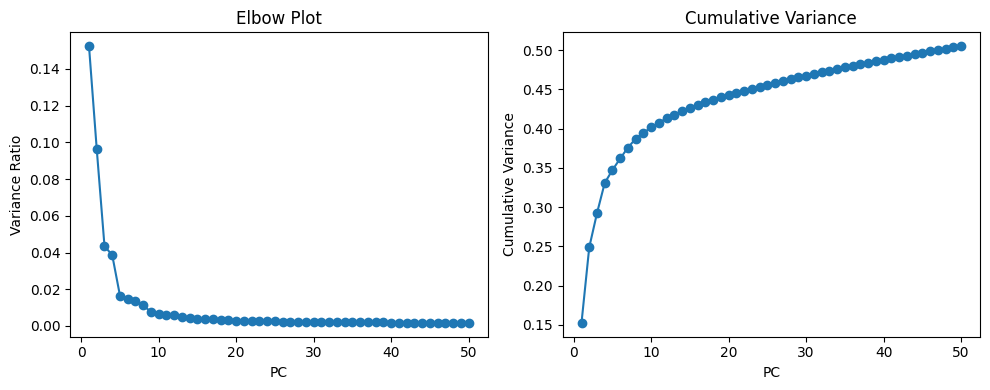

In [134]:
# Elbow plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

variance_ratio = adata_ctrl.uns['pca']['variance_ratio']
cumulative_var = np.cumsum(variance_ratio)

axes[0].plot(range(1, 51), variance_ratio, 'o-')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_title('Elbow Plot')

axes[1].plot(range(1, 51), cumulative_var, 'o-')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance')

plt.tight_layout()
plt.savefig('results/figures/elbow_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [137]:
# Keep only first 15 PCs
adata_ctrl.obsm['X_pca'] = adata_ctrl.obsm['X_pca'][:, :15]

print(f"PCA shape: {adata_ctrl.obsm['X_pca'].shape}")

PCA shape: (11290, 15)


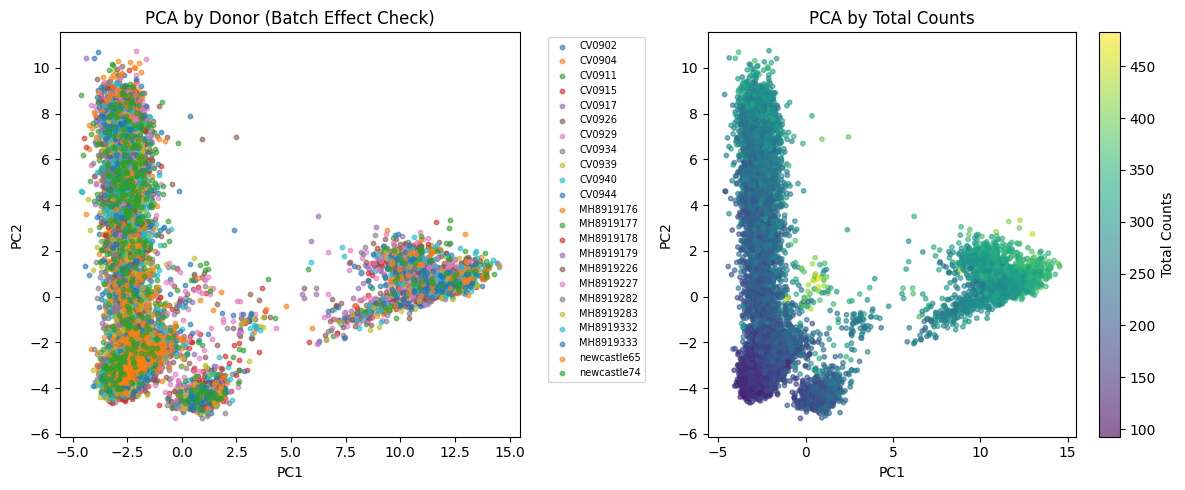

In [138]:
# PCA Sanity Check Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. PC1 vs PC2 by donor (batch effect check)
for donor in adata_ctrl.obs['patient_id'].unique():
    mask = adata_ctrl.obs['patient_id'] == donor
    axes[0].scatter(
        adata_ctrl.obsm['X_pca'][mask, 0],
        adata_ctrl.obsm['X_pca'][mask, 1],
        label=donor, alpha=0.6, s=10
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA by Donor (Batch Effect Check)')
axes[0].legend(bbox_to_anchor=(1.05, 1), fontsize=7)

# 2. PC1 vs PC2 by total counts (technical artifact check)
scatter = axes[1].scatter(
    adata_ctrl.obsm['X_pca'][:, 0],
    adata_ctrl.obsm['X_pca'][:, 1],
    c=np.array(adata_ctrl.X.sum(axis=1)).flatten(),
    cmap='viridis', alpha=0.6, s=10
)
plt.colorbar(scatter, ax=axes[1], label='Total Counts')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA by Total Counts')

plt.tight_layout()
plt.savefig('results/figures/PCA_batcheffect.png', dpi=300, bbox_inches='tight')
plt.show()

**Run Harmony**

In [139]:
# Re-run PCA (need full matrix for Harmony)
sc.tl.pca(adata_ctrl, n_comps=50, random_state=42)

# Run Harmony
ho = hm.run_harmony(
    adata_ctrl.obsm['X_pca'],
    adata_ctrl.obs,
    'patient_id'
)

# Store result (note: Z_corr needs transpose)
adata_ctrl.obsm['X_harmony'] = ho.Z_corr

2026-03-26 20:46:37,607 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-03-26 20:46:37,608 - harmonypy - INFO -   Parameters:
2026-03-26 20:46:37,608 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-26 20:46:37,609 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-26 20:46:37,610 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-26 20:46:37,611 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-26 20:46:37,612 - harmonypy - INFO -     nclust: 100
2026-03-26 20:46:37,613 - harmonypy - INFO -     block_size: 0.05
2026-03-26 20:46:37,614 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-03-26 20:46:37,615 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-03-26 20:46:37,616 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-26 20:46:37,617 - harmonypy - INFO -     verbose: True
2026-03-26 20:46:37,618 - harmonypy - INFO -     random

In [140]:
# Subset both to 15 PCs
adata_ctrl.obsm['X_pca'] = adata_ctrl.obsm['X_pca'][:, :15]
adata_ctrl.obsm['X_harmony'] = adata_ctrl.obsm['X_harmony'][:, :15]

print(f"PCA shape: {adata_ctrl.obsm['X_pca'].shape}")
print(f"Harmony shape: {adata_ctrl.obsm['X_harmony'].shape}")

PCA shape: (11290, 15)
Harmony shape: (11290, 15)


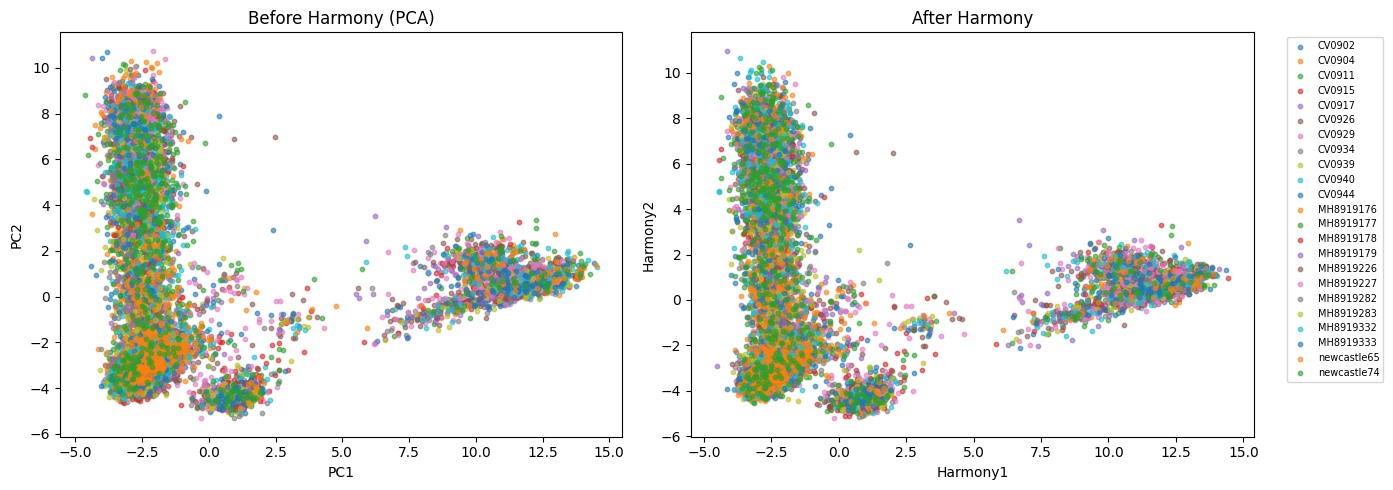

In [141]:
# Before vs After Harmony
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before (PCA)
for donor in adata_ctrl.obs['patient_id'].unique():
    mask = adata_ctrl.obs['patient_id'] == donor
    axes[0].scatter(
        adata_ctrl.obsm['X_pca'][mask, 0],
        adata_ctrl.obsm['X_pca'][mask, 1],
        label=donor, alpha=0.6, s=10
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Before Harmony (PCA)')

# After (Harmony)
for donor in adata_ctrl.obs['patient_id'].unique():
    mask = adata_ctrl.obs['patient_id'] == donor
    axes[1].scatter(
        adata_ctrl.obsm['X_harmony'][mask, 0],
        adata_ctrl.obsm['X_harmony'][mask, 1],
        label=donor, alpha=0.6, s=10
    )
axes[1].set_xlabel('Harmony1')
axes[1].set_ylabel('Harmony2')
axes[1].set_title('After Harmony')
axes[1].legend(bbox_to_anchor=(1.05, 1), fontsize=7)

plt.tight_layout()
plt.savefig('results/figures/harmony_effect.png', dpi=300, bbox_inches='tight')
plt.show()

In [142]:
# Silhouette Score (lower = better mixing)
from sklearn.metrics import silhouette_score

# Before Harmony
sil_before = silhouette_score(
    adata_ctrl.obsm['X_pca'],
    adata_ctrl.obs['patient_id']
)

# After Harmony
sil_after = silhouette_score(
    adata_ctrl.obsm['X_harmony'],
    adata_ctrl.obs['patient_id']
)

print(f"Silhouette Score (by donor):")
print(f"  Before Harmony: {sil_before:.4f}")
print(f"  After Harmony:  {sil_after:.4f}")
print(f"  (Lower = better mixing of donors)")

Silhouette Score (by donor):
  Before Harmony: -0.1372
  After Harmony:  -0.1615
  (Lower = better mixing of donors)


In [143]:
# Batch Entropy (higher = better mixing)
from sklearn.neighbors import NearestNeighbors

def batch_entropy(X, labels, n_neighbors=50):
    nn = NearestNeighbors(n_neighbors=n_neighbors).fit(X)
    indices = nn.kneighbors(return_distance=False)
    
    entropies = []
    for i, neighbors in enumerate(indices):
        neighbor_labels = labels[neighbors]
        _, counts = np.unique(neighbor_labels, return_counts=True)
        probs = counts / counts.sum()
        entropy = -np.sum(probs * np.log(probs + 1e-10))
        entropies.append(entropy)
    
    return np.mean(entropies)

labels = adata_ctrl.obs['patient_id'].values

ent_before = batch_entropy(adata_ctrl.obsm['X_pca'], labels)
ent_after = batch_entropy(adata_ctrl.obsm['X_harmony'], labels)

print(f"Batch Entropy:")
print(f"  Before Harmony: {ent_before:.4f}")
print(f"  After Harmony:  {ent_after:.4f}")
print(f"  (Higher = better mixing of donors)")

Batch Entropy:
  Before Harmony: 2.2157
  After Harmony:  2.5753
  (Higher = better mixing of donors)


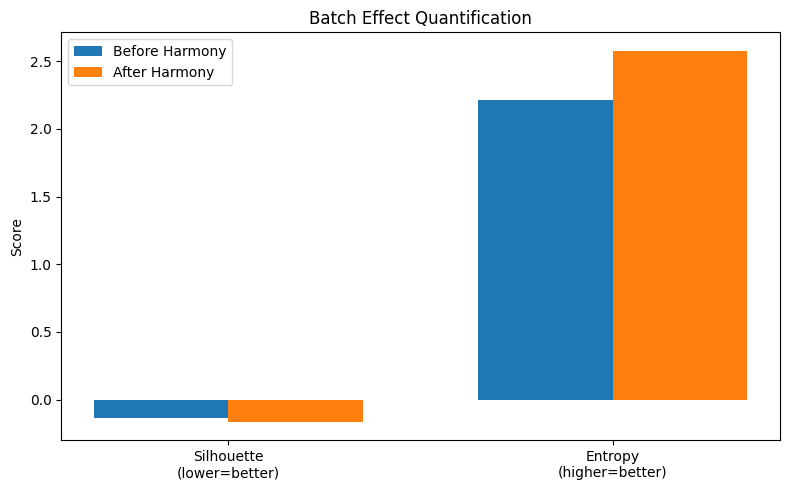

In [144]:
# Summary plot
fig, ax = plt.subplots(figsize=(8, 5))

metrics = ['Silhouette\n(lower=better)', 'Entropy\n(higher=better)']
before = [sil_before, ent_before]
after = [sil_after, ent_after]

x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, before, width, label='Before Harmony')
ax.bar(x + width/2, after, width, label='After Harmony')

ax.set_ylabel('Score')
ax.set_title('Batch Effect Quantification')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.savefig('results/figures/Batch_quantified.png', dpi=300, bbox_inches='tight')
plt.show()

**Extract scVI embeddings from processed data**

In [145]:
adata_ctrl.obsm

AxisArrays with keys: X_scVI, X_umap, X_pca, X_harmony

scVI embeddings already exist in the original dataset.

**Sanity checks and plots generation**

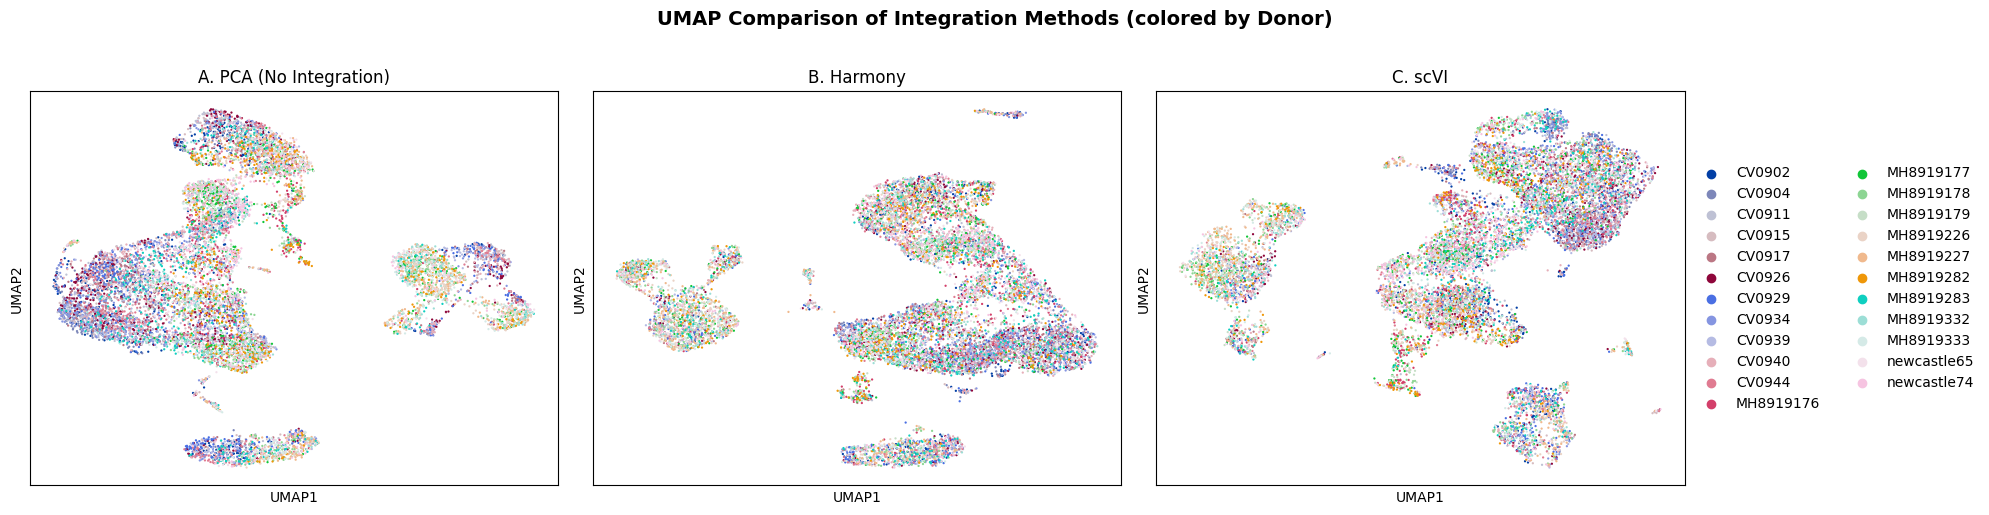

Saved: results/figures/umap_comparison.png


In [146]:
# Compute UMAPs on the copy

# PCA
sc.pp.neighbors(
    adata_ctrl, 
    use_rep="X_pca", 
    key_added="pca_neighbors",
    random_state=42
)
sc.tl.umap(
    adata_ctrl, 
    neighbors_key="pca_neighbors",
    random_state=42
)
adata_ctrl.obsm["X_umap_pca"] = adata_ctrl.obsm["X_umap"].copy()

# Harmony
sc.pp.neighbors(
    adata_ctrl, 
    use_rep="X_harmony", 
    key_added="harmony_neighbors",
    random_state=42
)
sc.tl.umap(
    adata_ctrl, 
    neighbors_key="harmony_neighbors",
    random_state=42
)
adata_ctrl.obsm["X_umap_harmony"] = adata_ctrl.obsm["X_umap"].copy()

# scVI
sc.pp.neighbors(
    adata_ctrl, 
    use_rep="X_scVI", 
    key_added="scvi_neighbors",
    random_state=42
)
sc.tl.umap(
    adata_ctrl, 
    neighbors_key="scvi_neighbors",
    random_state=42
)
adata_ctrl.obsm["X_umap_scvi"] = adata_ctrl.obsm["X_umap"].copy()


# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

fig.suptitle(
    'UMAP Comparison of Integration Methods (colored by Donor)', 
    fontsize=14, fontweight='bold', y=1.02
)

adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_pca"]
sc.pl.umap(
    adata_ctrl, color="patient_id", ax=axes[0],
    show=False, title="A. PCA (No Integration)", legend_loc=None
)

adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_harmony"]
sc.pl.umap(
    adata_ctrl, color="patient_id", ax=axes[1],
    show=False, title="B. Harmony", legend_loc=None
)

adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_scvi"]
sc.pl.umap(
    adata_ctrl, color="patient_id", ax=axes[2],
    show=False, title="C. scVI"
)

plt.tight_layout()
plt.savefig('results/figures/umap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: results/figures/umap_comparison.png")

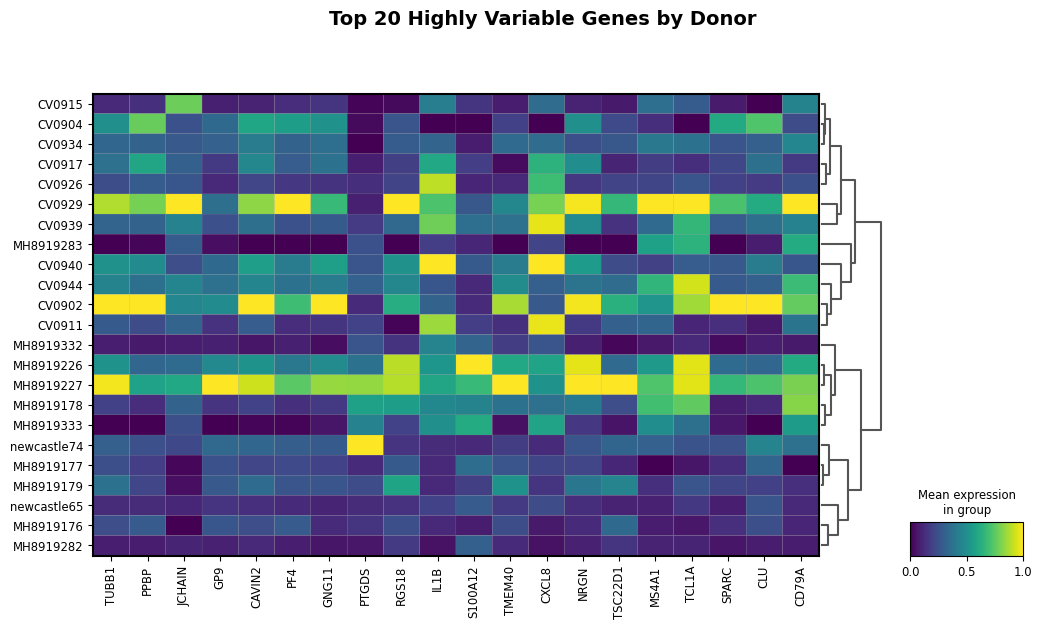


Saved: results/figures/heatmap_top_hvgs.png'


In [147]:
# Heatmap of top HVGs by variance - aggregated by patient
top_genes = adata_ctrl.var.sort_values('dispersions_norm', ascending=False).head(20).index

sc.tl.dendrogram(
    adata_ctrl,
    groupby='patient_id'
)

sc.pl.matrixplot(
    adata_ctrl,
    var_names=top_genes,
    groupby='patient_id',
    cmap='viridis',
    standard_scale='var',  # Scale each gene 0-1
    dendrogram=True,
    figsize=(12, 6),
    show=False
)

# Get current figure and add title
fig = plt.gcf()
fig.suptitle('Top 20 Highly Variable Genes by Donor', 
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig('results/figures/heatmap_top_hvgs.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: results/figures/heatmap_top_hvgs.png'")

/tmp/ipykernel_2098982/613495362.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_site = adata_ctrl.obs.groupby('patient_id')['Site'].first()
/tmp/ipykernel_2098982/613495362.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle


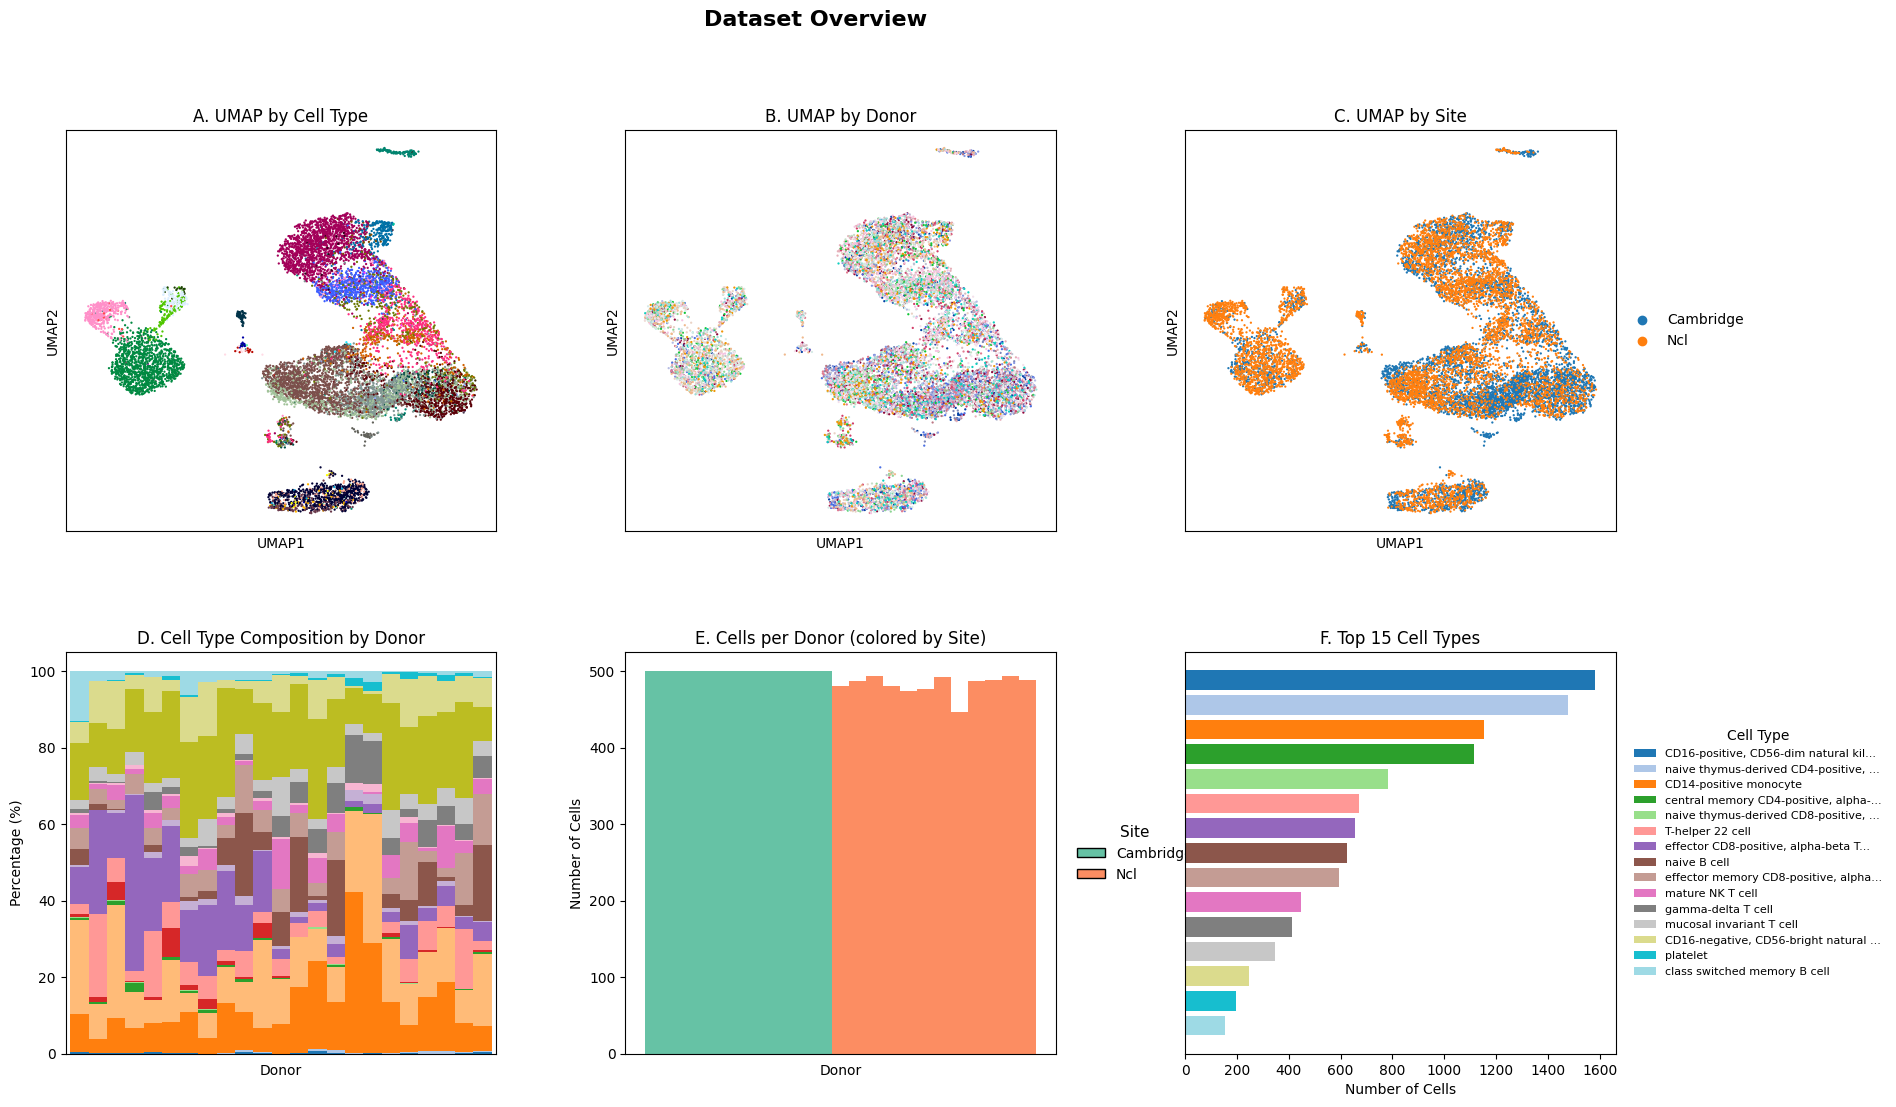


Saved: results/figures/dataset_overview.png


In [148]:
# Create Dataset Overview Figure
fig = plt.figure(figsize=(20, 12))

# Add overall title
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold', y=0.98)

# Define grid: 2 rows, custom column widths
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3, width_ratios=[1, 1, 1])

# Use one of the integrated representations for UMAP
adata_ctrl.obsm["X_umap"] = adata_ctrl.obsm["X_umap_harmony"]

# ------ Row 1 ------

# 1A: UMAP by cell type
ax1 = fig.add_subplot(gs[0, 0])
sc.pl.umap(adata_ctrl, color="cell_type", ax=ax1, show=False, 
           title="A. UMAP by Cell Type", frameon=True, legend_loc=None)

# 1B: UMAP by donor
ax2 = fig.add_subplot(gs[0, 1])
sc.pl.umap(adata_ctrl, color="patient_id", ax=ax2, show=False, 
           title="B. UMAP by Donor", frameon=True, legend_loc=None)

# 1C: UMAP by site
ax3 = fig.add_subplot(gs[0, 2])
sc.pl.umap(adata_ctrl, color="Site", ax=ax3, show=False, 
           title="C. UMAP by Site", frameon=True)

# ------ Row 2 ------

# 1D: Cell type composition per donor
ax4 = fig.add_subplot(gs[1, 0])
composition = pd.crosstab(adata_ctrl.obs['patient_id'], 
                          adata_ctrl.obs['cell_type'], 
                          normalize='index') * 100
composition.plot(kind='bar', stacked=True, ax=ax4, 
                 colormap='tab20', edgecolor='none', width=1.0, legend=False)
ax4.set_xlabel('Donor')
ax4.set_ylabel('Percentage (%)')
ax4.set_title('D. Cell Type Composition by Donor')
ax4.set_xticklabels([])
ax4.tick_params(axis='x', length=0)

# 1E: Cells per donor, colored by site
ax5 = fig.add_subplot(gs[1, 1])
donor_site = adata_ctrl.obs.groupby('patient_id')['Site'].first()
donor_counts = adata_ctrl.obs['patient_id'].value_counts().sort_index()

sites = donor_site.unique()
site_colors = dict(zip(sites, plt.cm.Set2.colors[:len(sites)]))
bar_colors = [site_colors[donor_site[donor]] for donor in donor_counts.index]

ax5.bar(range(len(donor_counts)), donor_counts.values, color=bar_colors, edgecolor='none', width=1.0)
ax5.set_xlabel('Donor')
ax5.set_ylabel('Number of Cells')
ax5.set_title('E. Cells per Donor (colored by Site)')
ax5.set_xticklabels([])
ax5.tick_params(axis='x', length=0)

# Legend on right
from matplotlib.patches import Patch
site_legend = [Patch(facecolor=site_colors[s], edgecolor='black', label=s) for s in sites]
ax5.legend(handles=site_legend, 
           loc='center left', 
           bbox_to_anchor=(1.02, 0.5),
           fontsize=10,
           frameon=False,
           title='Site',
           title_fontsize=11)

# 1F: Cell type abundance
ax6 = fig.add_subplot(gs[1, 2])
celltype_counts = adata_ctrl.obs['cell_type'].value_counts().head(15)
colors_ct = plt.cm.tab20(np.linspace(0, 1, len(celltype_counts)))

bars = ax6.barh(range(len(celltype_counts)), celltype_counts.values, color=colors_ct, edgecolor='none')
ax6.set_yticks([])
ax6.set_xlabel('Number of Cells')
ax6.set_title('F. Top 15 Cell Types')
ax6.invert_yaxis()

# Add legend to the right
short_names = [name[:35] + '...' if len(name) > 35 else name for name in celltype_counts.index]
ax6.legend(bars, short_names, loc='center left', bbox_to_anchor=(1.02, 0.5), 
           fontsize=8, title='Cell Type', frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
plt.savefig('results/figures/dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: results/figures/dataset_overview.png")

In [120]:
adata_ctrl

AnnData object with n_obs × n_vars = 11290 × 2000
    obs: 'Collection_Day', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', 'author_cell_type', 'organism', 'sex', 'tissue', 'ethnicity', 'disease', 'assay', 'cell_type', 'dataset_group'
    var: 'gene_id', 'gene_name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'umap', 'hvg', 'pca', 'pca_neighbors', 'harmony_neighbors', 'scvi_neighbors', 'patient_id_colors', 'dendrogram_patient_id', 'cell_type_colors', 'Site_colors'
    obsm: 'X_scVI', 'X_umap', 'X_pca', 'X_harmony', 'X_umap_pca', 'X_umap_harmony', 'X_umap_scvi'
    varm: 'PCs'
    obsp: 'pca_neighbors_distances', 'pca_neighbors_connectivities', 'harmony_neighbors_distances', 'harmony_neighbors_connectivities', 'scvi_neighbors_distances', 'scvi_nei

In [149]:
print("=== Verifying Representations for Classification ===\n")

# Check HVG expression
print(f"✓ adata.X (HVG expression): {adata_ctrl.X.shape}")

# Check raw expression
if adata_ctrl.raw is not None:
    print(f"✓ adata.raw.X (full expression): {adata_ctrl.raw.X.shape}")
else:
    print("✗ adata.raw is missing!")

# Check embeddings
embeddings = ['X_pca', 'X_harmony', 'X_scVI']
for emb in embeddings:
    if emb in adata_ctrl.obsm:
        print(f"✓ adata.obsm['{emb}']: {adata_ctrl.obsm[emb].shape}")
    else:
        print(f"✗ adata.obsm['{emb}'] is missing!")

# Check metadata
print(f"\n=== Metadata ===")
print(f"✓ Cell types: {adata_ctrl.obs['cell_type'].nunique()} unique")
print(f"✓ Donors: {adata_ctrl.obs['patient_id'].nunique()} unique")
print(f"✓ Total cells: {adata_ctrl.n_obs}")

=== Verifying Representations for Classification ===

✓ adata.X (HVG expression): (11290, 2000)
✓ adata.raw.X (full expression): (11290, 16299)
✓ adata.obsm['X_pca']: (11290, 15)
✓ adata.obsm['X_harmony']: (11290, 15)
✓ adata.obsm['X_scVI']: (11290, 10)

=== Metadata ===
✓ Cell types: 41 unique
✓ Donors: 23 unique
✓ Total cells: 11290


In [150]:
# Save processed adata
output_file = Path('data/adata_processed.h5ad')
adata_ctrl.write(output_file)

print(f"\n=== Saved ===")
print(f"File: {output_file}")
print(f"Size: {output_file.stat().st_size / 1e6:.1f} MB")


=== Saved ===
File: data/adata_processed.h5ad
Size: 168.6 MB


In [151]:
# Verify saved file
adata_test = ad.read_h5ad(output_file)

print("=== Final Verification (reloaded file) ===\n")
print(f"adata.X (HVG expression): {adata_test.X.shape}")
print(f"adata.raw.X (full expression): {adata_test.raw.X.shape}")
print(f"adata.obsm['X_pca']: {adata_test.obsm['X_pca'].shape}")
print(f"adata.obsm['X_harmony']: {adata_test.obsm['X_harmony'].shape}")
print(f"adata.obsm['X_scVI']: {adata_test.obsm['X_scVI'].shape}")
print(f"\nCell types: {adata_test.obs['cell_type'].nunique()}")
print(f"Donors: {adata_test.obs['patient_id'].nunique()}")
print(f"\n✓ Ready for classification benchmarking")

=== Final Verification (reloaded file) ===

adata.X (HVG expression): (11290, 2000)
adata.raw.X (full expression): (11290, 16299)
adata.obsm['X_pca']: (11290, 15)
adata.obsm['X_harmony']: (11290, 15)
adata.obsm['X_scVI']: (11290, 10)

Cell types: 41
Donors: 23

✓ Ready for classification benchmarking


In [124]:
print("""
=== Data Format Summary ===

File: results/data/adata_processed.h5ad

Representations:
  - adata.X           → HVG log-normalized expression (2000 genes)
  - adata.raw.X       → Full expression before HVG subsetting
  - adata.obsm['X_pca']     → PCA (5 components)
  - adata.obsm['X_harmony'] → Harmony-corrected PCs (5 components)
  - adata.obsm['X_scVI']    → scVI latent embeddings

Metadata:
  - adata.obs['cell_type']   → Classification target
  - adata.obs['patient_id']  → Donor ID (for donor-held-out splits)
  
Dataset:
  - 11,290 cells
  - 23 healthy donors
  - ~40 cell types
""")


=== Data Format Summary ===

File: results/data/adata_processed.h5ad

Representations:
  - adata.X           → HVG log-normalized expression (2000 genes)
  - adata.raw.X       → Full expression before HVG subsetting
  - adata.obsm['X_pca']     → PCA (5 components)
  - adata.obsm['X_harmony'] → Harmony-corrected PCs (5 components)
  - adata.obsm['X_scVI']    → scVI latent embeddings

Metadata:
  - adata.obs['cell_type']   → Classification target
  - adata.obs['patient_id']  → Donor ID (for donor-held-out splits)
  
Dataset:
  - 11,290 cells
  - 23 healthy donors
  - ~40 cell types

